In [1]:
# https://platform.olimpiada-ai.ro/ro/problems/240

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 

In [2]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/the-ghost-in-the-machine-dataset/train.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/the-ghost-in-the-machine-dataset/test.csv")

train.shape, test.shape

((6000, 16), (1500, 14))

In [3]:
def remove_brackets(text):
    met_start = False
    res = ''
    for s in text:
        if s == '[':
            met_start = True
        if not met_start:
            res += s
        if s == ']':
            met_start = False
    return res

def process(df):
    df['alert_title'] = df['alert_title'].map(lambda x: ' '.join([p for p in x.split() if not p.startswith('srv_')]).lower())
    df['system_log'] = df['system_log'].map(lambda x: remove_brackets(x.replace('\n', ' ')).lower())
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute
    df['sin_day_cycle'] = np.sin((df['hour'] * 60 + df['minute']) / 1440 * 2 * np.pi)
    df['cos_day_cycle'] = np.cos((df['hour'] * 60 + df['minute']) / 1440 * 2 * np.pi)
    df['hour'] = df['hour'].astype(str)
    df['minute'] = df['minute'].astype(str)
    df.drop(columns=['timestamp'], inplace=True)
    
process(train)
process(test)

In [4]:
train.head(2)

,id,server_id,region,server_type,cpu_usage,memory_usage,disk_io,network_latency,error_rate,temperature,health_score,alert_title,system_log,failure,anomaly_score,hour,minute,sin_day_cycle,cos_day_cycle
0,757,srv_000,us-east,gpu-v100,56.28,48.81,73.10,0.92,0.40,56.05,61.77,slow disk operations on,warn service.health: check latency 424ms (th...,0.0,6,0,0,0.00000,1.000000
1,3475,srv_000,eu-west,cpu-xeon,36.08,44.14,669.85,0.00,4.87,49.22,69.71,high memory consumption detected —,info service.health: all checks passed erro...,NaN,20,0,9,0.03926,0.999229


In [5]:
train.server_type.value_counts()

server_type
storage-nvme    1034
gpu-a100        1009
cpu-xeon        1004
gpu-v100         996
storage-hdd      981
cpu-epyc         976
Name: count, dtype: int64

In [6]:
train.region.value_counts()

region
ap-south      1017
eu-west       1003
us-west       1003
ap-east       1002
us-east        993
eu-central     982
Name: count, dtype: int64

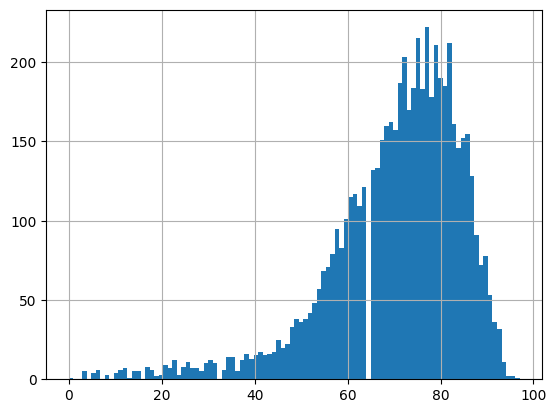

In [7]:
train.anomaly_score.hist(bins=100)
plt.show()

In [8]:
train.failure.dropna().value_counts()

failure
0.0    2874
1.0     702
Name: count, dtype: int64

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               6000 non-null   int64  
 1   server_id        6000 non-null   object 
 2   region           6000 non-null   object 
 3   server_type      6000 non-null   object 
 4   cpu_usage        5708 non-null   float64
 5   memory_usage     5691 non-null   float64
 6   disk_io          5707 non-null   float64
 7   network_latency  5705 non-null   float64
 8   error_rate       5693 non-null   float64
 9   temperature      5724 non-null   float64
 10  health_score     6000 non-null   float64
 11  alert_title      6000 non-null   object 
 12  system_log       6000 non-null   object 
 13  failure          3576 non-null   float64
 14  anomaly_score    6000 non-null   int64  
 15  hour             6000 non-null   object 
 16  minute           6000 non-null   object 
 17  sin_day_cycle 

In [10]:
from sklearn.model_selection import train_test_split
from catboost import Pool

def process_data(train, test, features, cat_features, text_features, target_col, do_stratify=False):
    X, y = train[features], train[target_col]
    X_test = test[features]

    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, stratify=y if do_stratify else None, random_state=42)
    train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=cat_features, text_features=text_features)

    return train_pool, valid_pool, X_test

In [11]:
features = [c for c in train.columns if c not in ['id', 'server_id', 'failure', 'anomaly_score']]
text_features = ['alert_title', 'system_log']
cat_features = [c for c in train.select_dtypes('object').columns if c in features and c not in text_features]

In [12]:
train_pool_s1, valid_pool_s1, X_test_s1 = process_data(train.iloc[np.where(~train.failure.isna())].reset_index(drop=True), test, features, cat_features, text_features, 'failure', do_stratify=True)
train_pool_s2, valid_pool_s2, X_test_s2 = process_data(train, test, features, cat_features, text_features, 'anomaly_score')

In [13]:
from catboost import CatBoostClassifier

params = {
    'iterations': 3000,
    'metric_period': 300,
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_state': 42,
    'max_depth': 2,
    'learning_rate': 0.1
}

clf = CatBoostClassifier(**params)

clf.fit(train_pool_s1, eval_set=valid_pool_s1)

0:	learn: 0.0000000	test: 0.0000000	best: 0.0000000 (0)	total: 72.6ms	remaining: 3m 37s
300:	learn: 0.6441718	test: 0.5242718	best: 0.5242718 (300)	total: 3.57s	remaining: 32s
600:	learn: 0.7462121	test: 0.6181818	best: 0.6181818 (600)	total: 7.02s	remaining: 28s
900:	learn: 0.8167730	test: 0.6428571	best: 0.6428571 (900)	total: 10.5s	remaining: 24.4s
1200:	learn: 0.8707124	test: 0.6428571	best: 0.6428571 (900)	total: 13.9s	remaining: 20.8s
1500:	learn: 0.8921739	test: 0.6306306	best: 0.6428571 (900)	total: 17.4s	remaining: 17.3s
1800:	learn: 0.9118905	test: 0.6491228	best: 0.6491228 (1800)	total: 20.7s	remaining: 13.8s
2100:	learn: 0.9255499	test: 0.6608696	best: 0.6608696 (2100)	total: 24.2s	remaining: 10.4s
2400:	learn: 0.9336692	test: 0.6491228	best: 0.6608696 (2100)	total: 27.7s	remaining: 6.91s
2700:	learn: 0.9443059	test: 0.6724138	best: 0.6724138 (2700)	total: 31.1s	remaining: 3.45s
2999:	learn: 0.9530091	test: 0.6666667	best: 0.6724138 (2700)	total: 34.6s	remaining: 0us

bestT

CatBoostClassifier(eval_metric='F1', iterations=3000, learning_rate=0.1, loss_function='Logloss', max_depth=2, metric_period=300, random_state=42)

In [14]:
from catboost import CatBoostRegressor

params = {
    'iterations': 1000,
    'metric_period': 100,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_state': 42,
    'max_depth': 2,
    'learning_rate': 0.1
}

reg = CatBoostRegressor(**params)

reg.fit(train_pool_s2, eval_set=valid_pool_s2)

0:	learn: 10.4599064	test: 10.8128323	best: 10.8128323 (0)	total: 18.2ms	remaining: 18.1s
100:	learn: 6.6175102	test: 6.5990087	best: 6.5990087 (100)	total: 1.46s	remaining: 13s
200:	learn: 6.1812581	test: 6.1698249	best: 6.1698249 (200)	total: 2.86s	remaining: 11.4s
300:	learn: 6.0214463	test: 6.1016169	best: 6.1016169 (300)	total: 4.27s	remaining: 9.92s
400:	learn: 5.9150812	test: 6.0852955	best: 6.0852955 (400)	total: 5.65s	remaining: 8.44s
500:	learn: 5.8340677	test: 6.0745552	best: 6.0745552 (500)	total: 7.06s	remaining: 7.04s
600:	learn: 5.7629646	test: 6.0603231	best: 6.0603231 (600)	total: 8.46s	remaining: 5.62s
700:	learn: 5.7049167	test: 6.0472978	best: 6.0472978 (700)	total: 9.81s	remaining: 4.18s
800:	learn: 5.6518083	test: 6.0470432	best: 6.0470432 (800)	total: 11.2s	remaining: 2.78s
900:	learn: 5.5987034	test: 6.0507193	best: 6.0470432 (800)	total: 12.5s	remaining: 1.38s
999:	learn: 5.5562990	test: 6.0559190	best: 6.0470432 (800)	total: 13.9s	remaining: 0us

bestTest = 6.

CatBoostRegressor(eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', max_depth=2, metric_period=100, random_state=42)

In [15]:
s1_preds = clf.predict(X_test_s1)
s2_preds = reg.predict(X_test_s2)

s1_preds.shape, s2_preds.shape

((1500,), (1500,))

In [16]:
np.bincount(s1_preds.astype(int))

array([1295,  205])

In [17]:
subm = pd.DataFrame({
    'id': test['id'].tolist() * 2,
    'subtaskID': [1] * len(s1_preds) + [2] * len(s2_preds),
    'answer': np.concatenate([s1_preds, s2_preds])
})

subm.to_csv("submission.csv", index=False)
subm.head()

,id,subtaskID,answer
0,0,1,0.0
1,1,1,0.0
2,2,1,0.0
3,3,1,0.0
4,4,1,0.0
